# 02 — Behavioral Analysis
Psychometric curves with sigmoid fits, PSE extraction, bootstrap CIs, and multi-pair analysis.

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# Set working directory to project root using package location
import neuromorph
os.chdir(os.path.dirname(os.path.dirname(neuromorph.__file__)))
print(f"Working directory: {os.getcwd()}")

import torch
import numpy as np
import matplotlib.pyplot as plt

from neuromorph.configs import ExperimentConfig
from neuromorph.training import set_global_seed, AutoencoderTrainer
from neuromorph.data import get_mnist_dataloaders
from neuromorph.analysis.psychometric import run_full_psychometric_pipeline
from neuromorph.visualization import apply_neuromorph_style, save_figure
from neuromorph.visualization.psychometric import plot_psychometric_curve, plot_pse_shift_summary

apply_neuromorph_style()

config = ExperimentConfig()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

set_global_seed(config.training.seed)

Working directory: C:\Users\matteucc\Desktop\Playground\NeuroMorph
Device: cuda


## Load Data and Models

In [2]:
train_dl, test_dl = get_mnist_dataloaders(batch_size=config.training.batch_size)

trainer = AutoencoderTrainer(config, device=device)
baseline_ae, association_ae = trainer.train(train_dl, retrain=False)

Loaded pretrained baseline and association models.


## Run Full Psychometric Pipeline
Runs for digit pairs (3,4), (3,5), and (3,8): collect examples → interpolate → train discriminator → evaluate → fit sigmoid → bootstrap → compute PSE shift.

In [3]:
results = run_full_psychometric_pipeline(
    baseline_ae, association_ae, test_dl, config, device,
    digit_pairs=[(3, 4), (3, 5), (3, 8)]
)


--- Psychometric pipeline for digits 3 vs 4 ---
Training Accuracy: 0.9931
Test Accuracy: 0.9850
  PSE (ctx):    0.2801 [0.2762, 0.2841]
  PSE (no ctx): 0.4032 [0.3996, 0.4083]
  Shift: -0.1231 (away_from_target), significant=True

--- Psychometric pipeline for digits 3 vs 5 ---
Training Accuracy: 0.8784
Test Accuracy: 0.9081
  PSE (ctx):    0.3476 [0.3424, 0.3539]
  PSE (no ctx): 0.4942 [0.4874, 0.5013]
  Shift: -0.1467 (away_from_target), significant=True

--- Psychometric pipeline for digits 3 vs 8 ---
Training Accuracy: 0.9382
Test Accuracy: 0.9244
  PSE (ctx):    0.3464 [0.3307, 0.3629]
  PSE (no ctx): 0.5079 [0.5036, 0.5122]
  Shift: -0.1615 (away_from_target), significant=True


## Psychometric Curves

Saved: ./output\02_psychometric_3_vs_4.png


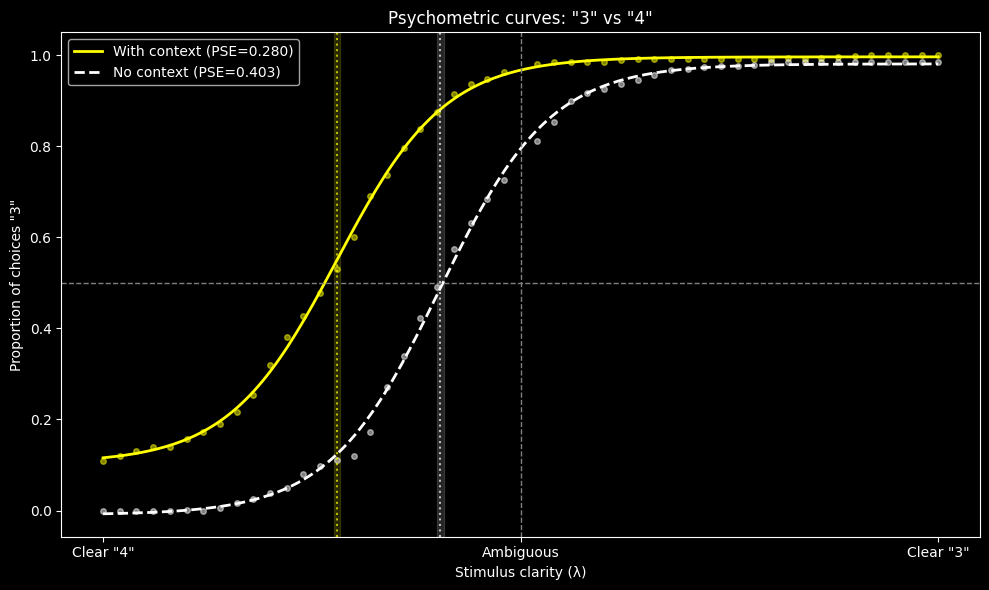

Saved: ./output\02_psychometric_3_vs_5.png


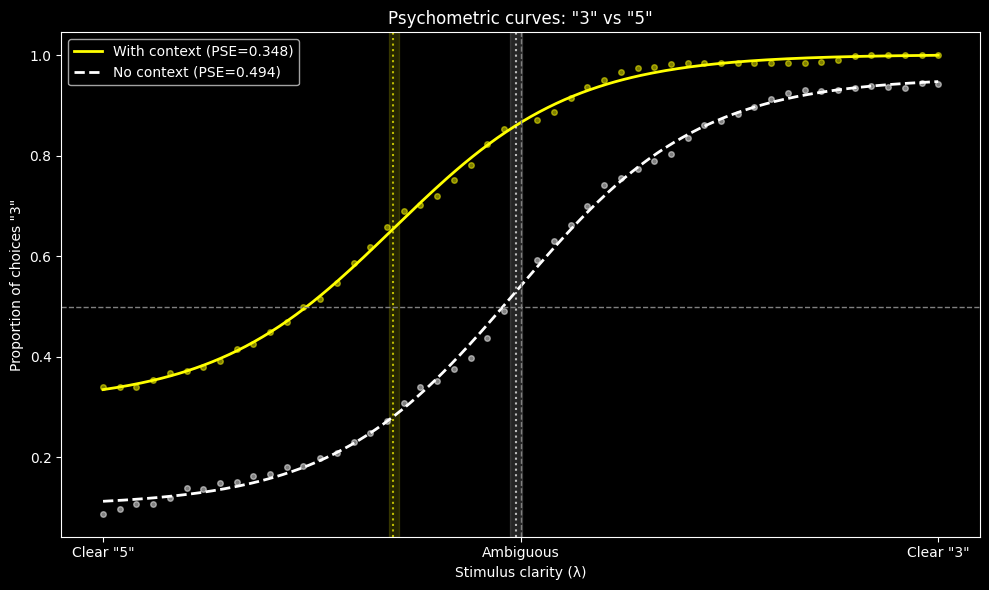

Saved: ./output\02_psychometric_3_vs_8.png


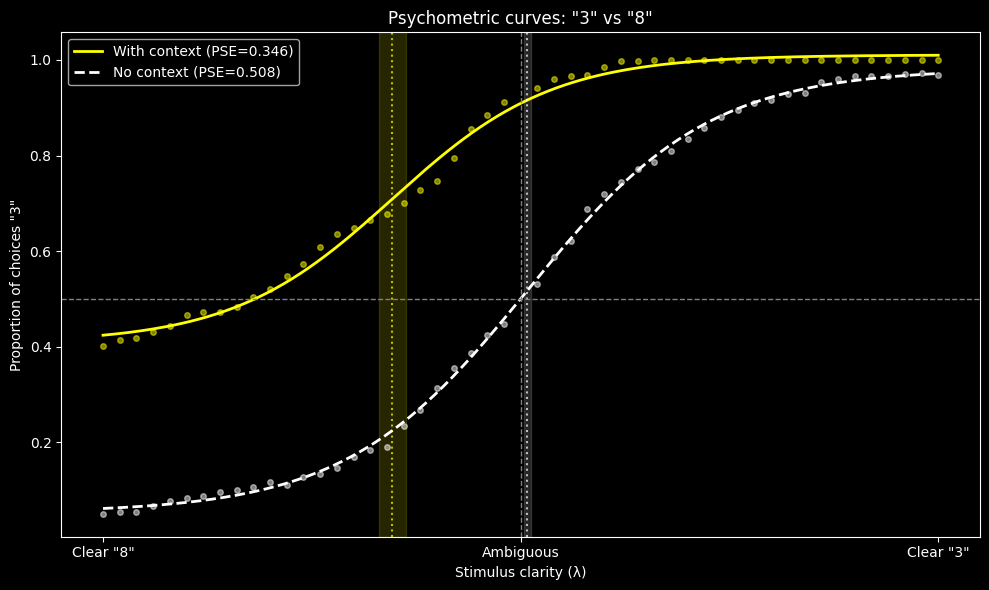

In [4]:
for (digit_a, digit_b), r in results.items():
    fig, ax = plt.subplots(figsize=(10, 6))
    plot_psychometric_curve(
        r['x_ctx'], r['prop_ctx'],
        r['x_no_ctx'], r['prop_no_ctx'],
        fit_ctx=r['fit_ctx'], fit_no_ctx=r['fit_no_ctx'],
        ci_ctx=r['shift']['ci_ctx'], ci_no_ctx=r['shift']['ci_no_ctx'],
        digit_a=digit_a, digit_b=digit_b, ax=ax
    )
    plt.tight_layout()
    save_figure(fig, f"02_psychometric_{digit_a}_vs_{digit_b}")
    plt.show()

## PSE Shift Summary

Saved: ./output\02_pse_shift_summary.png


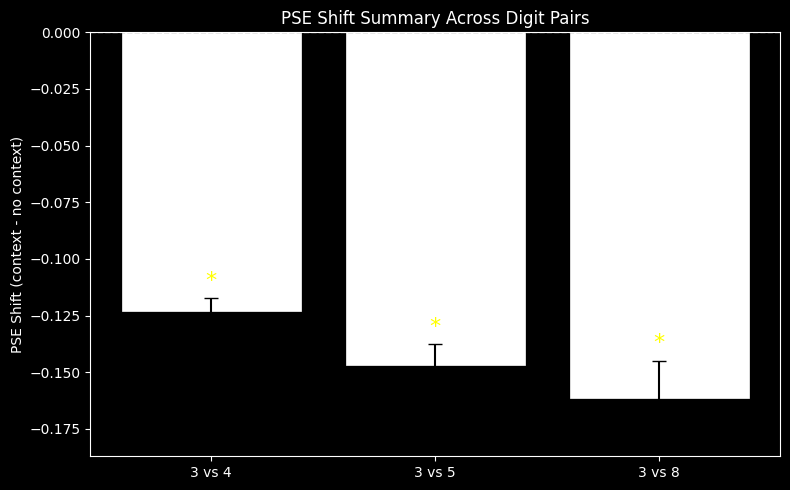


Pair        PSE (ctx) PSE (no ctx)    Shift  Significant
-------------------------------------------------------
3 vs 4         0.2801       0.4032  -0.1231         True
3 vs 5         0.3476       0.4942  -0.1467         True
3 vs 8         0.3464       0.5079  -0.1615         True


In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_pse_shift_summary(results, ax=ax)
plt.tight_layout()
save_figure(fig, "02_pse_shift_summary")
plt.show()

# Print summary table
print(f"\n{'Pair':<10} {'PSE (ctx)':>10} {'PSE (no ctx)':>12} {'Shift':>8} {'Significant':>12}")
print("-" * 55)
for (a, b), r in results.items():
    s = r['shift']
    print(f"{a} vs {b:<5} {s['pse_ctx']:>10.4f} {s['pse_no_ctx']:>12.4f} {s['shift']:>8.4f} {str(s['significant']):>12}")